## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Dataset + Libraries

In [2]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

business = pd.read_json("/content/drive/MyDrive/163/yelp_academic_dataset_business.json", lines=True)


## Filter for only restaurants

In [3]:
restaurants = business[
    business["categories"].str.contains("Restaurant", na=False)
]

restaurants.head(4)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."


## Filter for only restaurants with at least 50 reviews

In [39]:
restaurants = restaurants[restaurants["review_count"] >= 50]

In [40]:
restaurants["review_count"].min()

50

### 1. Summarize the dataset, including the target variable, features, and types of data

In [41]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20572 entries, 3 to 150323
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   20572 non-null  object 
 1   name          20572 non-null  object 
 2   address       20572 non-null  object 
 3   city          20572 non-null  object 
 4   state         20572 non-null  object 
 5   postal_code   20572 non-null  object 
 6   latitude      20572 non-null  float64
 7   longitude     20572 non-null  float64
 8   stars         20572 non-null  float64
 9   review_count  20572 non-null  int64  
 10  is_open       20572 non-null  int64  
 11  attributes    20571 non-null  object 
 12  categories    20572 non-null  object 
 13  hours         19956 non-null  object 
 14  status        20572 non-null  object 
 15  log_reviews   20572 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 2.7+ MB


In [42]:
restaurants.describe()

,latitude,longitude,stars,review_count,is_open,log_reviews
count,20572.000000,20572.000000,20572.000000,20572.000000,20572.000000,20572.000000
mean,36.257135,-88.505243,3.735077,191.419551,0.752965,4.902131
std,5.418866,14.238091,0.634729,269.404827,0.431298,0.743816
min,27.564457,-120.000083,1.000000,50.000000,0.000000,3.931826
25%,30.006135,-90.251018,3.500000,73.000000,1.000000,4.304065
50%,38.648581,-86.117725,4.000000,115.000000,1.000000,4.753590
75%,39.949485,-75.391203,4.000000,209.000000,1.000000,5.347108
max,53.649743,-74.699842,5.000000,7568.000000,1.000000,8.931816


In [43]:
restaurants["is_open"].value_counts()

,count
is_open,
1,15490
0,5082


### 2. Identify and handle missing, duplicate, or inconsistent data

In [45]:
#missing data
restaurants.isnull().sum()

,0
business_id,0
name,0
address,0
city,0
state,0
postal_code,0
latitude,0
longitude,0
stars,0
review_count,0


In [46]:
#business id duplicates
restaurants["business_id"].duplicated().sum()

np.int64(0)

## Visualizations

<Axes: xlabel='status', ylabel='Count'>

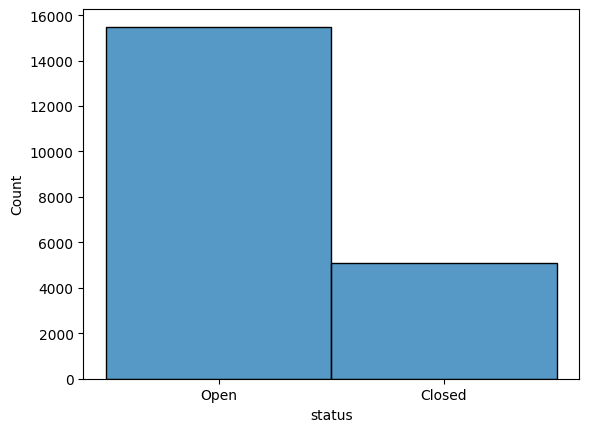

In [66]:
sns.histplot(x="status", data=restaurants)

In [44]:
restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})
fig = px.histogram(restaurants, x="status")
fig.show()



Many more open than closed restaurants

Text(0.5, 1.0, 'Distribution of Yelp Star Ratings')

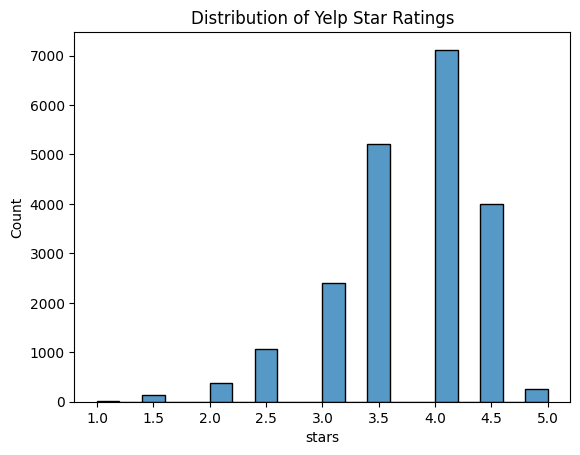

In [47]:
sns.histplot(restaurants["stars"], bins=20)
plt.title("Distribution of Yelp Star Ratings")

In [48]:
fig = px.histogram(
    restaurants,
    x="stars",
    nbins=20,
    title="Distribution of Yelp Star Ratings"
)

fig.show()

Most star ratings are 4

Text(0.5, 1.0, 'Distribution of Yelp Star Ratings by Restaurant Status')

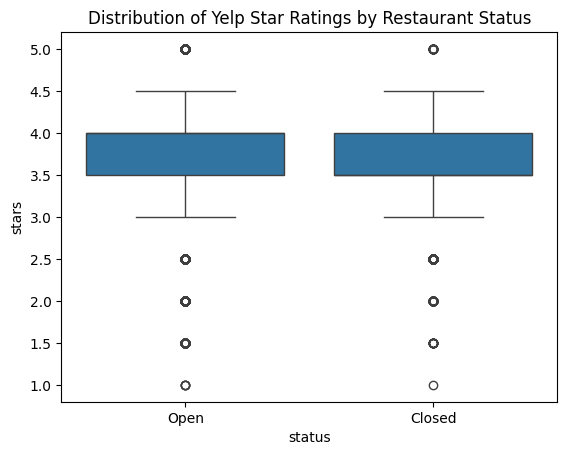

In [49]:
restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})
sns.boxplot(x="status", y="stars", data=restaurants)
plt.title("Distribution of Yelp Star Ratings by Restaurant Status")

In [50]:
fig = px.box(
    restaurants,
    x="status",
    y="stars",
    title="Distribution of Yelp Star Ratings by Restaurant Status"
)

fig.show()

Text(0.5, 1.0, 'Distribution of Yelp Star Ratings by Restaurant Status')

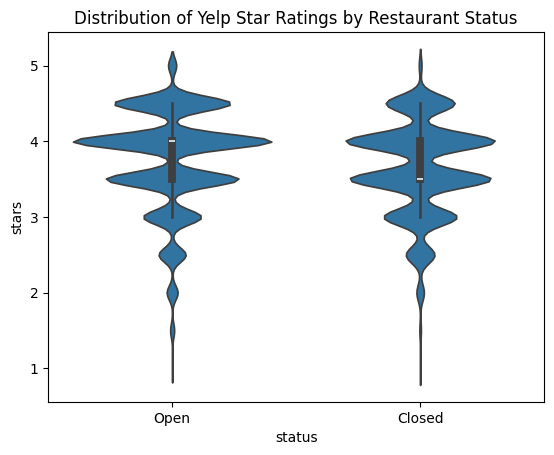

In [51]:
sns.violinplot(x="status", y="stars", data=restaurants)
plt.title("Distribution of Yelp Star Ratings by Restaurant Status")

In [52]:
fig = px.violin(
    restaurants,
    x="status",
    y="stars",
    box=True,        # shows mini boxplot inside
    points="outliers",
    title="Distribution of Yelp Star Ratings by Restaurant Status"
)

fig.show()

In [53]:
avg_rating_by_status = restaurants.groupby("status")["stars"].mean()
avg_rating_by_status

,stars
status,
Closed,3.643152
Open,3.765236


Text(0.5, 1.0, 'Average Yelp Star Ratings by Restaurant Status')

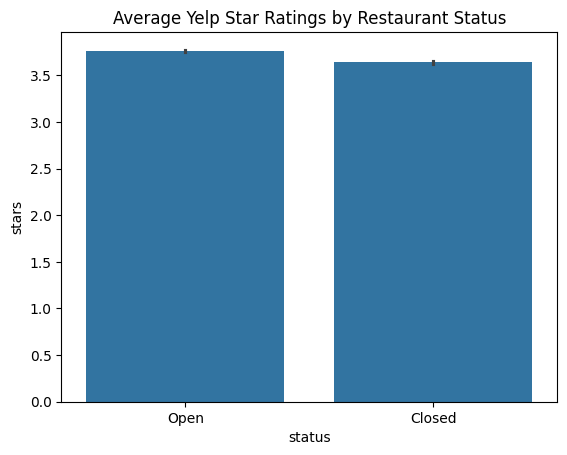

In [54]:
sns.barplot(x="status", y="stars", data=restaurants)
plt.title("Average Yelp Star Ratings by Restaurant Status")

In [55]:
avg_rating = restaurants.groupby("status")["stars"].mean().reset_index()

fig = px.bar(
    avg_rating,
    x="status",
    y="stars",
    title="Average Yelp Star Ratings by Restaurant Status",
    text="stars"
)

fig.show()

Both open and closed restaurants have very close medians. So Yelp star ratings alone is not a strong indicator if a restaurant stays open

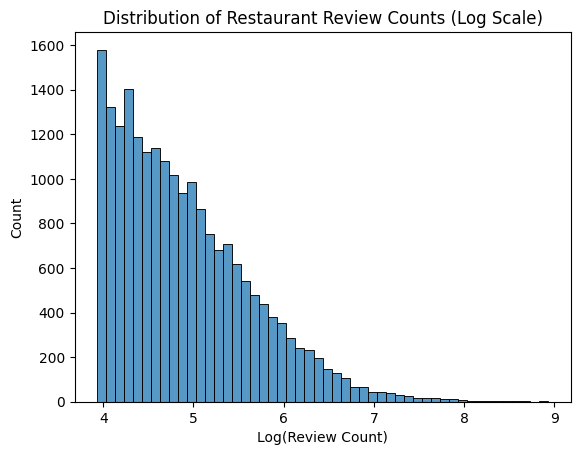

In [56]:
sns.histplot(np.log1p(restaurants["review_count"]), bins=50)
plt.xlabel("Log(Review Count)")
plt.title("Distribution of Restaurant Review Counts (Log Scale)")
plt.show()

In [57]:
restaurants["log_reviews"] = np.log1p(restaurants["review_count"])

fig = px.histogram(
    restaurants,
    x="log_reviews",
    nbins=50,
    title="Distribution of Restaurant Review Counts (Log Scale)"
)

fig.show()

Text(0.5, 1.0, 'Distribution of Review Counts by Restaurant Status')

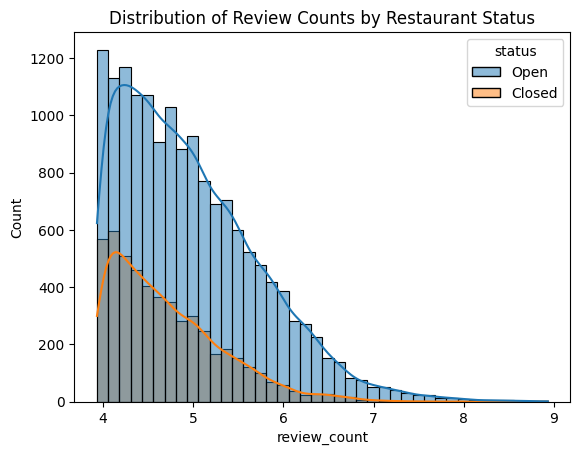

In [58]:
sns.histplot(data=restaurants, x=np.log1p(restaurants["review_count"]), hue="status", bins=40, kde=True)
plt.title("Distribution of Review Counts by Restaurant Status")

In [67]:
fig = px.histogram(
    restaurants,
    x="log_reviews",
    color="status",
    nbins=40,
    barmode="overlay",
    opacity=0.6,
    histnorm="probability density",
    title="Distribution of Review Counts by Restaurant Status"
)

fig.show()

Text(0.5, 1.0, 'Review Count by Restaurant Status')

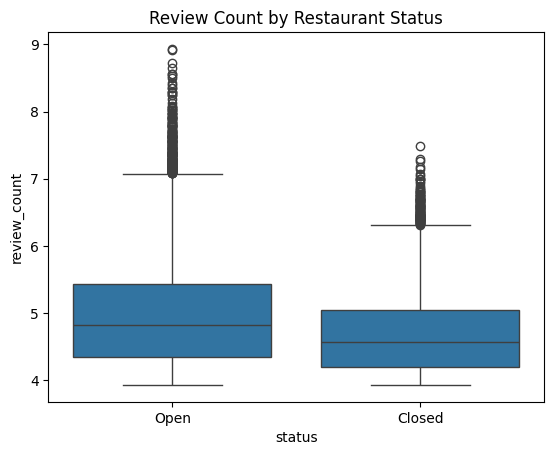

In [60]:
#do open restaurants have more reviews?
sns.boxplot(x="status", y=np.log1p(restaurants["review_count"]), data=restaurants)
plt.title("Review Count by Restaurant Status")

In [61]:
fig = px.box(
    restaurants,
    x="status",
    y="log_reviews",
    title="Review Count by Restaurant Status"
)

fig.show()

open restaurants have a higher median review count. (open restaurants have more reviews than closed ones). open restaurants have more high review outliers which can suggest that more popular restaurants can be more likely to be operating.

In [62]:
restaurants.groupby("status")["review_count"].mean()

,review_count
status,
Closed,136.684179
Open,209.377276


In [63]:
restaurants[["stars","review_count"]].corr()

,stars,review_count
stars,1.000000,0.135993
review_count,0.135993,1.000000


<Axes: >

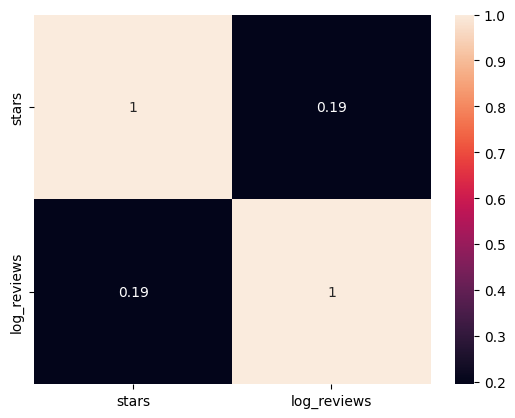

In [69]:
sns.heatmap(restaurants[["stars","log_reviews"]].corr(), annot=True)

In [71]:
import plotly.graph_objects as go

corr = restaurants[["stars", "log_reviews"]].corr()

fig = go.Figure(
    data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        text=np.round(corr.values, 2),
        texttemplate="%{text}",
        colorscale="RdBu"
    )
)

fig.update_layout(title="Correlation Heatmap")

fig.show()